# Cross-Year Winning-Coalition Entropy Analysis

Stability is measured as **Shannon entropy** over the coalition coverage
distribution:
- **low entropy**  -> one (or a few) coalitions explain almost all wins
  (a dominant, stable strategy)
- **high entropy** -> wins are spread across many coalitions
  (no dominant strategy that year)

For the lowest- and highest-entropy years details are provided

## 0. Configuration

In [11]:
import os
from itertools import combinations
from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

# ===== EDIT THESE for a different range / location =====
PF_DIR = "/home/ramesh/Code/nba_fantasy/eda_results/"   # where pf_{year}.csv live
PF_TEMPLATE = "pf_{year}.csv"
YEAR_START, YEAR_END = 2000, 2016
YEARS = range(YEAR_START, YEAR_END + 1)

MIN_WIN_RATE = 0.5    # same semantics as the single-year notebook: prune to
                       # strong points first, then score within that subset.
                       # Set to None to analyse the entire front each year.
CHUNK = 2000
TOP_N_COMBOS = 25
ACCENT = "#3B6EA5"

OUTPUT_DIR = "coalition_entropy_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1. Per-year analysis

Factors the single-year notebook's sections 1-4 (load front, pairwise scan,
minimal winning coalitions, coverage), section 7 (category centrality), and
section 10 (best pick) into one function, `analyze_year`, so it can be called
once per year.

In [12]:
def analyze_year(year):
    path = os.path.join(PF_DIR, PF_TEMPLATE.format(year=year))
    if not os.path.exists(path):
        print(f"[{year}] skip: {path} not found")
        return None

    front = pd.read_csv(path)
    objectives = list(front.columns)
    X = front.to_numpy(dtype=float)
    N, D = X.shape
    if D < 3:
        print(f"[{year}] skip: need D >= 3 objectives for a strict majority, got {D}")
        return None

    m = D // 2 + 1                                  # minimal winning-coalition size
    majority_sizes = list(range(m, D))              # m .. D-1 (strict majority, below full)
    weights = (1 << np.arange(D)).astype(np.int64)
    bmdt = np.int16 if D <= 15 else (np.int32 if D <= 31 else np.int64)

    def pairwise_scan(data):
        n = len(data)
        wc = np.zeros(n, dtype=np.int64)
        lc = np.zeros(n, dtype=np.int64)
        bits = np.zeros(1 << D, dtype=np.int64)
        for s in range(0, n, CHUNK):
            e = min(s + CHUNK, n)
            b = e - s
            wins_b = np.zeros((b, n), dtype=np.int16)
            bm = np.zeros((b, n), dtype=bmdt)
            for d in range(D):
                gd = data[s:e, d][:, None] > data[:, d][None, :]
                wins_b += gd
                bm += gd * bmdt(weights[d])
            loc, glob = np.arange(b), np.arange(s, e)
            wins_b[loc, glob] = 0
            maj = np.isin(wins_b, majority_sizes)
            maj[loc, glob] = False
            wc[s:e] = maj.sum(1)
            lc += maj.sum(0)
            bits += np.bincount(bm[maj], minlength=1 << D)
            del wins_b, maj, bm
        return wc, lc, bits

    win_count, loss_count, bit_counts = pairwise_scan(X)

    if MIN_WIN_RATE is not None:
        keep = win_count / (N - 1) >= MIN_WIN_RATE
        if keep.sum() < 2:
            print(f"[{year}] skip: fewer than 2 points survive MIN_WIN_RATE={MIN_WIN_RATE}")
            return None
        X = X[keep]
        N = len(X)
        win_count, loss_count, bit_counts = pairwise_scan(X)

    total_wins = int(win_count.sum())
    if total_wins == 0:
        print(f"[{year}] skip: no majority-win comparisons")
        return None

    # ----- minimal winning coalitions & coverage (sections 3-5) -----
    def label_of(combo):
        return "+".join(objectives[d] for d in combo)

    def bitmask_of(combo):
        return sum(1 << d for d in combo)

    coalitions = [{"indices": c, "label": label_of(c), "bitmask": bitmask_of(c)}
                  for c in combinations(range(D), m)]

    coverage = Counter()
    for W in np.flatnonzero(bit_counts):
        c = int(bit_counts[W])
        members = [d for d in range(D) if (W >> d) & 1]
        for sub in combinations(members, m):
            coverage[bitmask_of(sub)] += c

    results = pd.DataFrame(coalitions)
    results["coverage"] = results["bitmask"].map(lambda b: coverage.get(b, 0))
    results["pct"] = 100 * results["coverage"] / total_wins
    results = results.sort_values(["coverage", "label"], ascending=[False, True]).reset_index(drop=True)

    # ----- category centrality (section 7) -----
    central = []
    for _, r in results.iterrows():
        for d in r["indices"]:
            central.append({"objective": objectives[d], "coverage": r["coverage"]})
    central = (pd.DataFrame(central).groupby("objective", as_index=False)["coverage"].sum()
               .set_index("objective").reindex(objectives).reset_index()
               .sort_values("coverage", ascending=False))

    # ----- best pick (section 10) -----
    win_rate = win_count / (N - 1)
    best_idx = int(win_rate.argmax())

    return dict(
        year=year, N=N, D=D, m=m, objectives=objectives,
        total_wins=total_wins, results=results, central=central,
        win_rate=win_rate, best_idx=best_idx, X=X,
        bit_counts=bit_counts, majority_sizes=majority_sizes,
    )

## 2. Entropy of the winning-coalition distribution

`coalition_entropy` is the one to look at day-to-day — entropy over section
5's coalition coverage table, renormalized to sum to 1. Max possible entropy
is `log2(C(D, m))` (every coalition equally covered = least stable); 0 means
a single coalition explains every win (fully dominant strategy).

Caveat: coverage double-counts overlapping coalitions (one comparison can
credit several), so that renormalized distribution isn't a strict outcome
partition. `exact_winset_entropy` is a stricter cross-check computed over the
*exact* win-set distribution (`bit_counts`), which **is** a true, non-overlapping
partition of outcomes.

In [13]:
def shannon_entropy(counts):
    """Shannon entropy in bits over a vector of non-negative counts/weights."""
    p = np.asarray(counts, dtype=float)
    p = p[p > 0]
    if p.size == 0:
        return 0.0
    p = p / p.sum()
    return float(-(p * np.log2(p)).sum())


def coalition_entropy(year_result):
    return shannon_entropy(year_result["results"]["coverage"].to_numpy())


def exact_winset_entropy(year_result):
    bc = year_result["bit_counts"]
    popcount = np.array([bin(w).count("1") for w in range(len(bc))])
    mask = np.isin(popcount, year_result["majority_sizes"])
    return shannon_entropy(bc[mask])

## 3. Run across years

In [14]:
rows = []
year_results = {}
for year in YEARS:
    res = analyze_year(year)
    if res is None:
        continue
    year_results[year] = res
    n_coal = len(res["results"])
    rows.append(dict(
        year=year,
        n_points=res["N"],
        n_categories=res["D"],
        n_minimal_coalitions=n_coal,
        max_possible_entropy=np.log2(n_coal),
        coalition_entropy=coalition_entropy(res),
        exact_winset_entropy=exact_winset_entropy(res),
        top_coalition=res["results"].iloc[0]["label"],
        top_coalition_pct=res["results"].iloc[0]["pct"],
    ))
    print(f"[{year}] N={res['N']} D={res['D']} top coalition = "
          f"{res['results'].iloc[0]['label']} ({res['results'].iloc[0]['pct']:.1f}%)")

if not rows:
    raise SystemExit("No years produced results -- check PF_DIR / PF_TEMPLATE / YEARS.")

entropy_df = pd.DataFrame(rows).sort_values("year").reset_index(drop=True)
entropy_df["normalized_entropy"] = entropy_df["coalition_entropy"] / entropy_df["max_possible_entropy"]

entropy_csv = os.path.join(OUTPUT_DIR, "coalition_entropy_by_year.csv")
entropy_df.to_csv(entropy_csv, index=False)
print(f"\nWrote {entropy_csv}")
entropy_df[["year", "n_points", "n_minimal_coalitions", "coalition_entropy",
            "normalized_entropy", "top_coalition", "top_coalition_pct"]]

[2000] N=7518 D=5 top coalition = STL+3P+AST (31.9%)
[2001] N=6350 D=5 top coalition = STL+3P+AST (34.6%)
[2002] N=6039 D=5 top coalition = STL+3P+AST (33.1%)
[2003] N=6056 D=5 top coalition = STL+3P+AST (33.7%)
[2004] N=4487 D=5 top coalition = STL+3P+AST (37.1%)
[2005] N=4614 D=5 top coalition = STL+3P+AST (32.1%)
[2006] N=5302 D=5 top coalition = STL+3P+AST (31.5%)
[2007] N=5226 D=5 top coalition = STL+3P+AST (32.3%)
[2008] N=4073 D=5 top coalition = STL+3P+AST (34.2%)
[2009] N=5222 D=5 top coalition = STL+3P+AST (33.4%)
[2010] N=4856 D=5 top coalition = STL+3P+AST (34.1%)
[2011] N=7604 D=5 top coalition = STL+3P+AST (28.9%)
[2012] N=7119 D=5 top coalition = STL+3P+AST (31.2%)
[2013] N=6556 D=5 top coalition = STL+3P+AST (34.6%)
[2014] N=5619 D=5 top coalition = STL+3P+AST (33.2%)
[2015] N=4763 D=5 top coalition = STL+3P+AST (31.9%)
[2016] N=3713 D=5 top coalition = STL+3P+AST (35.7%)

Wrote coalition_entropy_results/coalition_entropy_by_year.csv


,year,n_points,n_minimal_coalitions,coalition_entropy,normalized_entropy,top_coalition,top_coalition_pct
0,2000,7518,10,3.097377,0.932403,STL+3P+AST,31.866204
1,2001,6350,10,3.005954,0.904882,STL+3P+AST,34.634832
2,2002,6039,10,3.059118,0.920886,STL+3P+AST,33.058624
3,2003,6056,10,2.980743,0.897293,STL+3P+AST,33.713689
4,2004,4487,10,2.920514,0.879162,STL+3P+AST,37.079378
5,2005,4614,10,2.986898,0.899146,STL+3P+AST,32.095908
6,2006,5302,10,2.993918,0.901259,STL+3P+AST,31.486635
7,2007,5226,10,3.024724,0.910533,STL+3P+AST,32.329221
8,2008,4073,10,2.963323,0.892049,STL+3P+AST,34.164726
9,2009,5222,10,3.050890,0.918409,STL+3P+AST,33.434878


## 4. Stability across years

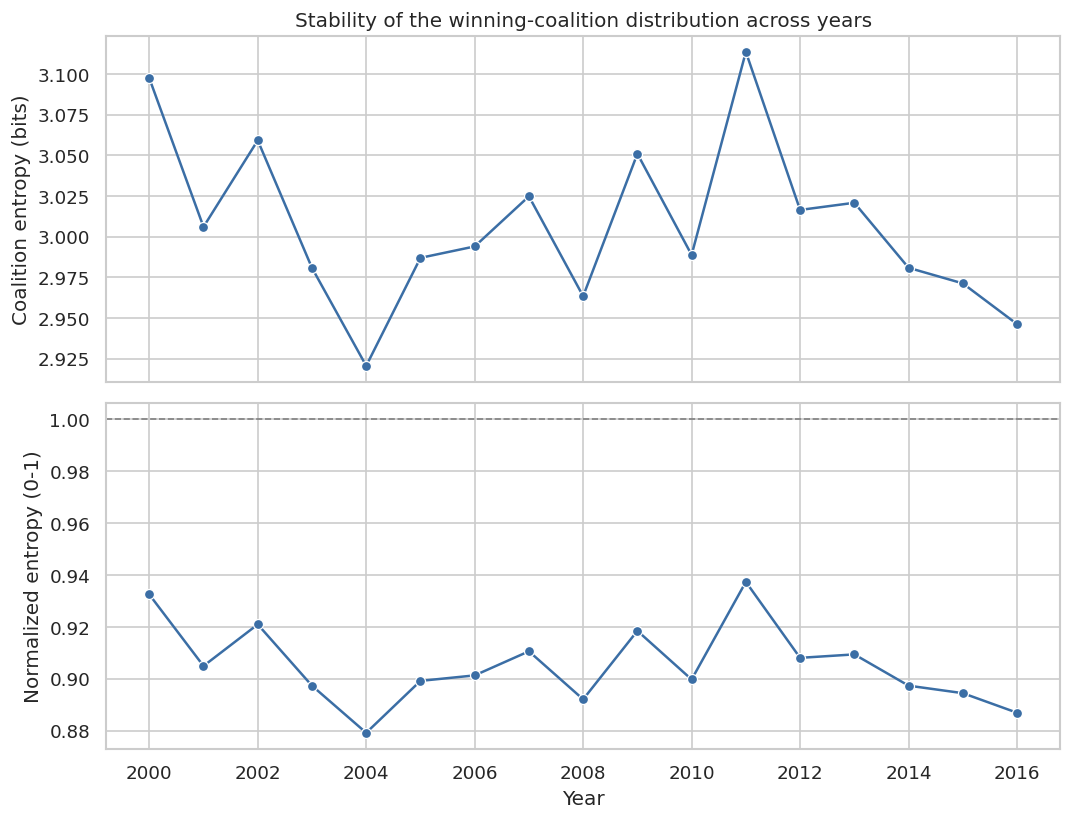

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
sns.lineplot(data=entropy_df, x="year", y="coalition_entropy", marker="o", ax=axes[0], color=ACCENT)
axes[0].set_ylabel("Coalition entropy (bits)")
axes[0].set_title("Stability of the winning-coalition distribution across years")

sns.lineplot(data=entropy_df, x="year", y="normalized_entropy", marker="o", ax=axes[1], color=ACCENT)
axes[1].axhline(1.0, ls="--", color="grey", lw=1)
axes[1].set_ylabel("Normalized entropy (0-1)")
axes[1].set_xlabel("Year")
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "entropy_by_year.png"))
plt.show()

## 5. Extreme-entropy years

Which year is closest to a single dominant strategy, and which is the most
unstable / spread-out?

In [16]:
lo_year = int(entropy_df.loc[entropy_df["coalition_entropy"].idxmin(), "year"])
hi_year = int(entropy_df.loc[entropy_df["coalition_entropy"].idxmax(), "year"])
print(f"Lowest-entropy year (most concentrated / dominant strategy):  {lo_year}")
print(f"Highest-entropy year (most spread-out / least stable strategy): {hi_year}")

Lowest-entropy year (most concentrated / dominant strategy):  2004
Highest-entropy year (most spread-out / least stable strategy): 2011


## 6. Year detail: coalition table, category centrality, best pick

Same detail as sections 5, 7, 10 of the single-year notebook, reproduced for
the two extreme years above.

In [17]:
def show_year_detail(year):
    res = year_results[year]
    print(f"===== {year} detail =====")
    print(f"points analysed: {res['N']}   categories: {res['D']}   minimal size m: {res['m']}")

    # section 5: coalition table
    tbl = res["results"][["label", "coverage", "pct"]].head(TOP_N_COMBOS)
    display(tbl.style.format({"pct": "{:.2f}%"}).hide(axis="index")
            .set_caption(f"{year}: minimal winning coalitions"))

    # section 7: category centrality
    display(res["central"].style.hide(axis="index").set_caption(f"{year}: category centrality"))

    # section 10: best pick
    best = res["best_idx"]
    print(f"Best pick: point {best}  win rate {res['win_rate'][best]:.3f}  "
          f"values = {dict(zip(res['objectives'], res['X'][best].round(2)))}")

    # coverage plot
    n_show = min(TOP_N_COMBOS, len(res["results"]))
    plot_df = res["results"].head(n_show)
    fig, ax = plt.subplots(figsize=(9, max(4, 0.34 * n_show + 1)))
    sns.barplot(data=plot_df, y="label", x="coverage", color=ACCENT, ax=ax)
    ax.set_title(f"{year}: coverage by minimal winning coalition")
    ax.set_xlabel(f"Matchup wins covered (winner took all {res['m']} of these categories)")
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, f"coalition_coverage_{year}.png"))
    plt.show()

    # centrality plot
    fig, ax = plt.subplots(figsize=(max(8, 1.15 * res["D"]), 4.5))
    sns.barplot(data=res["central"], x="objective", y="coverage", color=ACCENT, ax=ax)
    ax.set_title(f"{year}: category centrality")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, f"category_centrality_{year}.png"))
    plt.show()

### Lowest-entropy year

===== 2004 detail =====
points analysed: 4487   categories: 5   minimal size m: 3


label,coverage,pct
STL+3P+AST,3731702,37.08%
STL+TRB+BLK,2731240,27.14%
3P+TRB+BLK,1205935,11.98%
AST+TRB+BLK,1190669,11.83%
STL+AST+BLK,1150671,11.43%
STL+AST+TRB,1003308,9.97%
STL+3P+BLK,689448,6.85%
3P+AST+BLK,614558,6.11%
STL+3P+TRB,367902,3.66%
3P+AST+TRB,281253,2.79%


objective,coverage
STL,9674271
AST,7972161
BLK,7582521
3P,6890798
TRB,6780307


Best pick: point 4122  win rate 0.916  values = {'STL': np.float64(18.69), '3P': np.float64(17.67), 'AST': np.float64(58.59), 'TRB': np.float64(43.26), 'BLK': np.float64(6.58)}


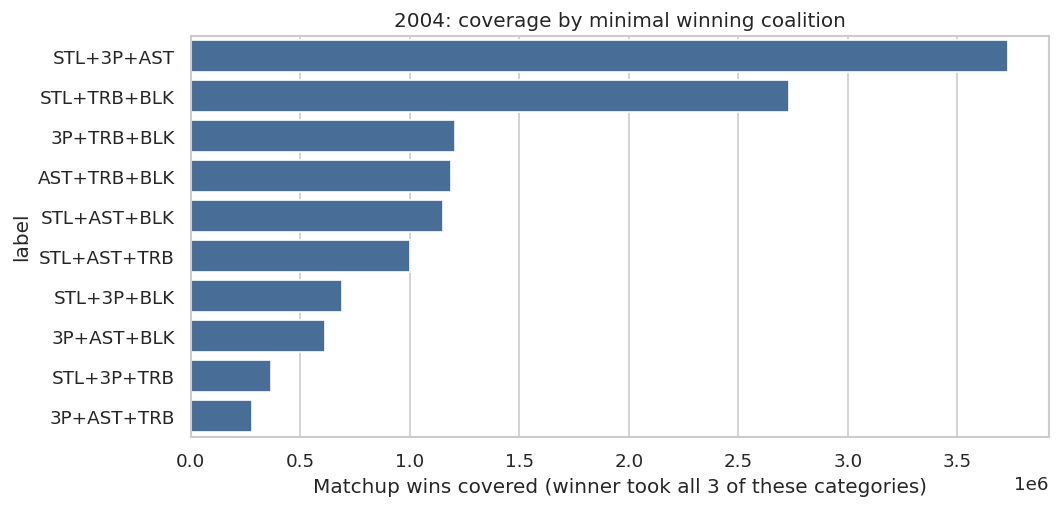

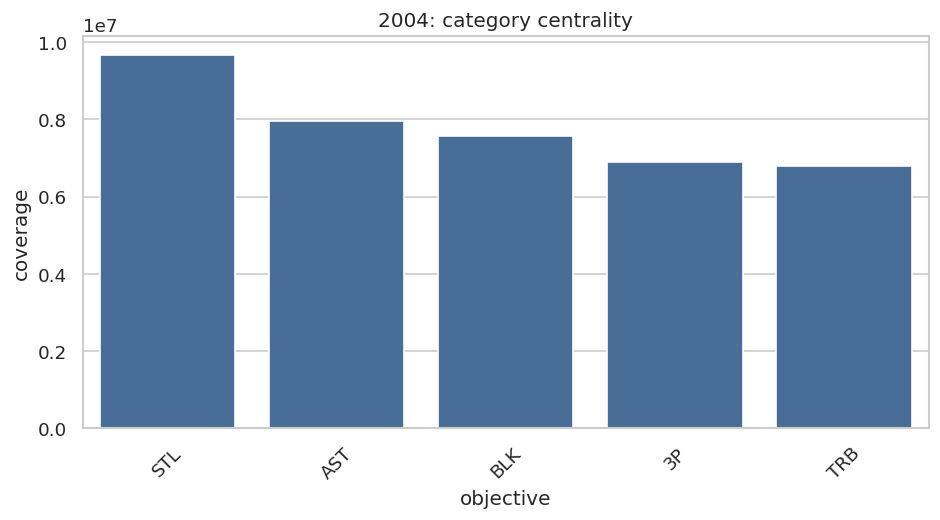

In [18]:
show_year_detail(lo_year)

### Highest-entropy year

===== 2011 detail =====
points analysed: 7604   categories: 5   minimal size m: 3


label,coverage,pct
STL+3P+AST,8353667,28.90%
STL+TRB+BLK,6032364,20.87%
3P+TRB+BLK,4613260,15.96%
STL+AST+BLK,3732324,12.91%
STL+AST+TRB,3632476,12.57%
AST+TRB+BLK,3024844,10.46%
3P+AST+BLK,1914774,6.62%
3P+AST+TRB,1907405,6.60%
STL+3P+TRB,1836608,6.35%
STL+3P+BLK,1629624,5.64%


objective,coverage
STL,25217063
AST,22565490
TRB,21046957
BLK,20947190
3P,20255338


Best pick: point 7373  win rate 0.906  values = {'STL': np.float64(17.58), '3P': np.float64(3.01), 'AST': np.float64(42.35), 'TRB': np.float64(78.85), 'BLK': np.float64(14.3)}


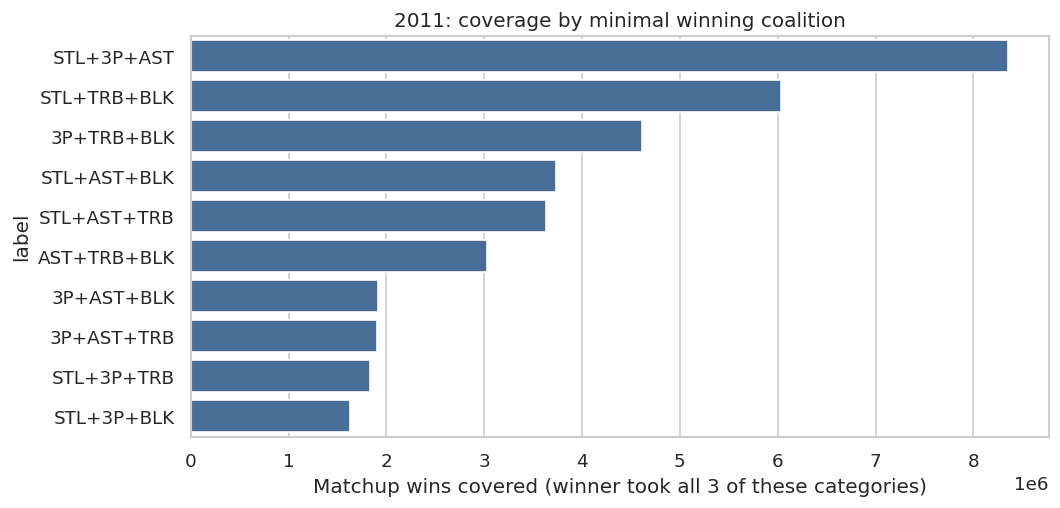

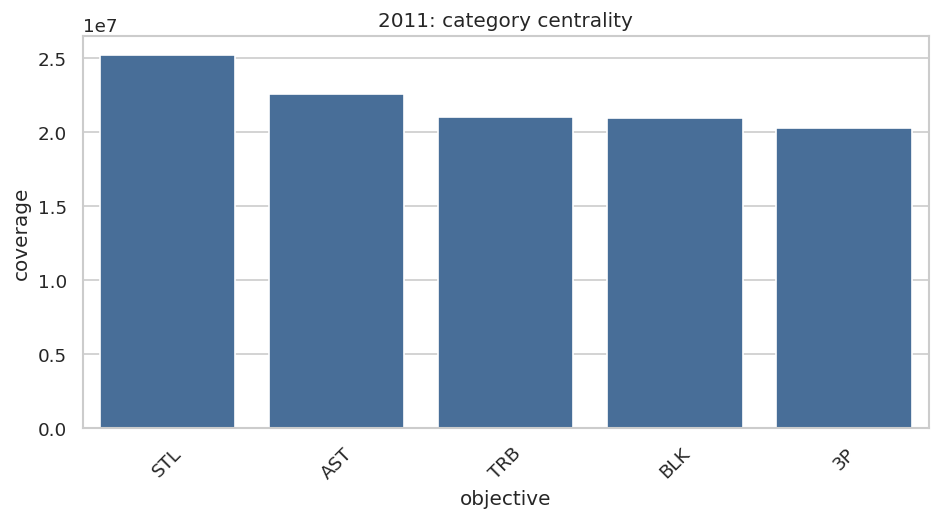

In [19]:
if hi_year != lo_year:
    show_year_detail(hi_year)
else:
    print("Lowest- and highest-entropy years coincide -- only one year in range, or a tie.")

In [20]:
print(f"All outputs written to: {os.path.abspath(OUTPUT_DIR)}")

All outputs written to: /home/ramesh/Code/nba_fantasy/coalition_entropy_results
